# Imports
initial imports of libraries and modules used in the notebook.

In [774]:
# Standard library
import os

# Third-party — data science stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Reading

[Link to Dataset](https://www.kaggle.com/datasets/rohitudageri/credit-card-details)

In [775]:
label_df = pd.read_csv('./Credit_card_label.csv')
data_df = pd.read_csv('./Credit_card.csv')

# concat the two dataframes where the Ind_ID is the same
df = pd.merge(data_df, label_df, on='Ind_ID')
df

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2,1
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2,1
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1543,5028645,F,N,Y,0,NaN,Commercial associate,Higher education,Married,House / apartment,-11957.0,-2182,1,0,0,0,Managers,2,0
1544,5023655,F,N,N,0,225000.0,Commercial associate,Incomplete higher,Single / not married,House / apartment,-10229.0,-1209,1,0,0,0,Accountants,1,0
1545,5115992,M,Y,Y,2,180000.0,Working,Higher education,Married,House / apartment,-13174.0,-2477,1,0,0,0,Managers,4,0
1546,5118219,M,Y,N,0,270000.0,Working,Secondary / secondary special,Civil marriage,House / apartment,-15292.0,-645,1,1,1,0,Drivers,2,0


In [776]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ind_ID           1548 non-null   int64  
 1   GENDER           1541 non-null   object 
 2   Car_Owner        1548 non-null   object 
 3   Propert_Owner    1548 non-null   object 
 4   CHILDREN         1548 non-null   int64  
 5   Annual_income    1525 non-null   float64
 6   Type_Income      1548 non-null   object 
 7   EDUCATION        1548 non-null   object 
 8   Marital_status   1548 non-null   object 
 9   Housing_type     1548 non-null   object 
 10  Birthday_count   1526 non-null   float64
 11  Employed_days    1548 non-null   int64  
 12  Mobile_phone     1548 non-null   int64  
 13  Work_Phone       1548 non-null   int64  
 14  Phone            1548 non-null   int64  
 15  EMAIL_ID         1548 non-null   int64  
 16  Type_Occupation  1060 non-null   object 
 17  Family_Members

In [777]:
df.duplicated().sum()

np.int64(0)

To ensure, drop the duplicates from the dataset and check the number of duplicates that were removed.

In [778]:
df.drop_duplicates(inplace=True)

In [779]:
df.columns

Index(['Ind_ID', 'GENDER', 'Car_Owner', 'Propert_Owner', 'CHILDREN',
       'Annual_income', 'Type_Income', 'EDUCATION', 'Marital_status',
       'Housing_type', 'Birthday_count', 'Employed_days', 'Mobile_phone',
       'Work_Phone', 'Phone', 'EMAIL_ID', 'Type_Occupation', 'Family_Members',
       'label'],
      dtype='object')

To ensure consistency, lowercase all the columns and strip the whitespaces on the columns

In [780]:
# lower case all the columns
df.columns = df.columns.str.lower()

# strip the columns of whitespace
df.columns = df.columns.str.strip()

df.columns

Index(['ind_id', 'gender', 'car_owner', 'propert_owner', 'children',
       'annual_income', 'type_income', 'education', 'marital_status',
       'housing_type', 'birthday_count', 'employed_days', 'mobile_phone',
       'work_phone', 'phone', 'email_id', 'type_occupation', 'family_members',
       'label'],
      dtype='object')

In [781]:
df.describe()

,ind_id,children,annual_income,birthday_count,employed_days,mobile_phone,work_phone,phone,email_id,family_members,label
count,1.548000e+03,1548.000000,1.525000e+03,1526.000000,1548.000000,1548.0,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000
mean,5.078920e+06,0.412791,1.913993e+05,-16040.342071,59364.689922,1.0,0.208010,0.309432,0.092377,2.161499,0.113049
std,4.171759e+04,0.776691,1.132530e+05,4229.503202,137808.062701,0.0,0.406015,0.462409,0.289651,0.947772,0.316755
min,5.008827e+06,0.000000,3.375000e+04,-24946.000000,-14887.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
25%,5.045070e+06,0.000000,1.215000e+05,-19553.000000,-3174.500000,1.0,0.000000,0.000000,0.000000,2.000000,0.000000
50%,5.078842e+06,0.000000,1.665000e+05,-15661.500000,-1565.000000,1.0,0.000000,0.000000,0.000000,2.000000,0.000000
75%,5.115673e+06,1.000000,2.250000e+05,-12417.000000,-431.750000,1.0,0.000000,1.000000,0.000000,3.000000,0.000000
max,5.150412e+06,14.000000,1.575000e+06,-7705.000000,365243.000000,1.0,1.000000,1.000000,1.000000,15.000000,1.000000


In [782]:
# Drop the id. It is not relevant to the analysis and can be used to identify individuals in the dataset.
df.drop(columns=['ind_id'], inplace=True)

# Also drop the mobile_phone column as all the values are the same and it is not relevant to the analysis.
df.drop(columns=['mobile_phone'], inplace=True)

df.head()

,gender,car_owner,propert_owner,children,annual_income,type_income,education,marital_status,housing_type,birthday_count,employed_days,work_phone,phone,email_id,type_occupation,family_members,label
0,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,0,0,0,NaN,2,1
1,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,0,NaN,2,1
2,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,0,NaN,2,1
3,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,0,NaN,2,1
4,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,0,NaN,2,1


In [783]:
df.isnull().sum()

gender               7
car_owner            0
propert_owner        0
children             0
annual_income       23
type_income          0
education            0
marital_status       0
housing_type         0
birthday_count      22
employed_days        0
work_phone           0
phone                0
email_id             0
type_occupation    488
family_members       0
label                0
dtype: int64

In [784]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           1541 non-null   object 
 1   car_owner        1548 non-null   object 
 2   propert_owner    1548 non-null   object 
 3   children         1548 non-null   int64  
 4   annual_income    1525 non-null   float64
 5   type_income      1548 non-null   object 
 6   education        1548 non-null   object 
 7   marital_status   1548 non-null   object 
 8   housing_type     1548 non-null   object 
 9   birthday_count   1526 non-null   float64
 10  employed_days    1548 non-null   int64  
 11  work_phone       1548 non-null   int64  
 12  phone            1548 non-null   int64  
 13  email_id         1548 non-null   int64  
 14  type_occupation  1060 non-null   object 
 15  family_members   1548 non-null   int64  
 16  label            1548 non-null   int64  
dtypes: float64(2),

The DTypes are correct. But there are some missing values in the `gender`, `annual_income`, `birthday_count` and the `employed_days` column.

First, Remove the type_occupation column as it has a lot of missing values

In [785]:
df.drop(columns=['type_occupation'], inplace=True)

Use an Imputer for the rest of the columns

In [786]:
from sklearn.impute import SimpleImputer

In [787]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['number']).columns

# create an imputer for the categorical columns
categorical_imputer = SimpleImputer(strategy='most_frequent')
# create an imputer for the numerical columns
numerical_imputer = SimpleImputer(strategy='median')

# fit the imputer on the categorical columns
for col in categorical_cols:
    df[col] = categorical_imputer.fit_transform(df[[col]]).ravel()

# fit the imputer on the numerical columns
for col in numerical_cols:
    df[col] = numerical_imputer.fit_transform(df[[col]]).ravel()

In [788]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          1548 non-null   object 
 1   car_owner       1548 non-null   object 
 2   propert_owner   1548 non-null   object 
 3   children        1548 non-null   float64
 4   annual_income   1548 non-null   float64
 5   type_income     1548 non-null   object 
 6   education       1548 non-null   object 
 7   marital_status  1548 non-null   object 
 8   housing_type    1548 non-null   object 
 9   birthday_count  1548 non-null   float64
 10  employed_days   1548 non-null   float64
 11  work_phone      1548 non-null   float64
 12  phone           1548 non-null   float64
 13  email_id        1548 non-null   float64
 14  family_members  1548 non-null   float64
 15  label           1548 non-null   float64
dtypes: float64(9), object(7)
memory usage: 193.6+ KB


In [789]:
df.isna().sum()

gender            0
car_owner         0
propert_owner     0
children          0
annual_income     0
type_income       0
education         0
marital_status    0
housing_type      0
birthday_count    0
employed_days     0
work_phone        0
phone             0
email_id          0
family_members    0
label             0
dtype: int64

As seen in the data, there seems to have a value under `employed_days` that occurs multiple times. The value is 365243.

In [790]:
# Get the rows with the value 365243 in the employed_days column
df[df['employed_days'] == 365243].count()

gender            261
car_owner         261
propert_owner     261
children          261
annual_income     261
type_income       261
education         261
marital_status    261
housing_type      261
birthday_count    261
employed_days     261
work_phone        261
phone             261
email_id          261
family_members    261
label             261
dtype: int64

There are 261 rows with the value 365243 in the employed_days column.

Let's transform the value 365243 in the employed_days column to NaN for now

In [791]:
# Transform these values to NaN as they are likely to be outliers or errors in the data.
# additionally we can use these later for feature engineering to create a new feature
# that indicates whether they are employed or not.
df["employed_days"] = df["employed_days"].replace(365243, np.nan)

In [792]:
df.head()

,gender,car_owner,propert_owner,children,annual_income,type_income,education,marital_status,housing_type,birthday_count,employed_days,work_phone,phone,email_id,family_members,label
0,M,Y,Y,0.0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,NaN,0.0,0.0,0.0,2.0,1.0
1,F,Y,N,0.0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586.0,1.0,1.0,0.0,2.0,1.0
2,F,Y,N,0.0,315000.0,Commercial associate,Higher education,Married,House / apartment,-15661.5,-586.0,1.0,1.0,0.0,2.0,1.0
3,F,Y,N,0.0,166500.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586.0,1.0,1.0,0.0,2.0,1.0
4,F,Y,N,0.0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586.0,1.0,1.0,0.0,2.0,1.0


Ensure that there are no more missing values in the dataset and that the DTypes are correct.

In [793]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          1548 non-null   object 
 1   car_owner       1548 non-null   object 
 2   propert_owner   1548 non-null   object 
 3   children        1548 non-null   float64
 4   annual_income   1548 non-null   float64
 5   type_income     1548 non-null   object 
 6   education       1548 non-null   object 
 7   marital_status  1548 non-null   object 
 8   housing_type    1548 non-null   object 
 9   birthday_count  1548 non-null   float64
 10  employed_days   1287 non-null   float64
 11  work_phone      1548 non-null   float64
 12  phone           1548 non-null   float64
 13  email_id        1548 non-null   float64
 14  family_members  1548 non-null   float64
 15  label           1548 non-null   float64
dtypes: float64(9), object(7)
memory usage: 193.6+ KB


# EDA

Since `phone`, `work_phone`, `email_id` has 0 or 1 values, transform these columns to boolean values where 0 is False and 1 is True for the sake of EDA.

In [794]:
eda_df = df.copy()

eda_df["phone"] = eda_df["phone"].astype(bool)
eda_df["work_phone"] = eda_df["work_phone"].astype(bool)
eda_df["email_id"] = eda_df["email_id"].astype(bool)

Define the numerical and categorical columns

In [795]:
eda_numerical_cols = eda_df.select_dtypes(include=['number']).columns
eda_categorical_cols = eda_df.select_dtypes(include=['bool', 'object']).columns

In [796]:
eda_df.describe()

,children,annual_income,birthday_count,employed_days,family_members,label
count,1548.000000,1.548000e+03,1548.000000,1287.000000,1548.000000,1548.000000
mean,0.412791,1.910294e+05,-16034.958010,-2666.575758,2.161499,0.113049
std,0.776691,1.124483e+05,4199.561035,2397.536850,0.947772,0.316755
min,0.000000,3.375000e+04,-24946.000000,-14887.000000,1.000000,0.000000
25%,0.000000,1.215000e+05,-19476.000000,-3505.500000,2.000000,0.000000
50%,0.000000,1.665000e+05,-15661.500000,-1953.000000,2.000000,0.000000
75%,1.000000,2.250000e+05,-12483.000000,-931.500000,3.000000,0.000000
max,14.000000,1.575000e+06,-7705.000000,-73.000000,15.000000,1.000000


In [797]:
# helper function to interpret level of skewness
def interpret_skewness(skew_value):
    if skew_value > 1:
        return "highly positively skewed"
    elif skew_value > 0.5:
        return "moderately positively skewed"
    elif skew_value > 0:
        return "slightly positively skewed"
    elif skew_value < -1:
        return "highly negatively skewed"
    elif skew_value < -0.5:
        return "moderately negatively skewed"
    elif skew_value < 0:
        return "slightly negatively skewed"
    else:
        return "symmetrical distribution"

In [798]:
# Get the skewness of the numerical columns
skewness = df[eda_numerical_cols].skew()

skewness_interpretation = skewness.apply(interpret_skewness)

print("Skewness of numerical columns:")
print(skewness)
print("\nInterpretation of skewness:")
print(skewness_interpretation)

Skewness of numerical columns:
children          4.631122
annual_income     3.959453
birthday_count   -0.176124
employed_days    -1.687212
family_members    2.232273
label             2.446379
dtype: float64

Interpretation of skewness:
children            highly positively skewed
annual_income       highly positively skewed
birthday_count    slightly negatively skewed
employed_days       highly negatively skewed
family_members      highly positively skewed
label               highly positively skewed
dtype: object


We can see that most of the columns has a a highly positively skewed distribution. This is expected as most of the customers will have a low credit limit and a low balance. However, there are some customers who have a high credit limit and a high balance, which is why we see a long tail in the distribution.

Decision: Basing on the results of the skewness, avoid using log transformations. Instead, Use plot types based on feature behavior for clearer EDA.

- Evaluate first the target variable distribution to understand the class imbalance and choose appropriate evaluation metrics for modeling.
- Use a violinplot for each of the numerical columns to see the differences in medians, quartiles, and outliers between the classes

Exception: The `annual_income` can be log transformed to reduce the skewness and make the distribution more normal. This can help improve the performance of some machine learning algorithms that assume normality. However, it is important to note that log transformation can also make the interpretation of the data more difficult, as the values will be in a different scale. Therefore, it is important to carefully consider whether log transformation is appropriate for the `annual_income` column before applying it.

In [799]:
target_col = "label"

Evaluate the target variable

<Axes: xlabel='label', ylabel='count'>

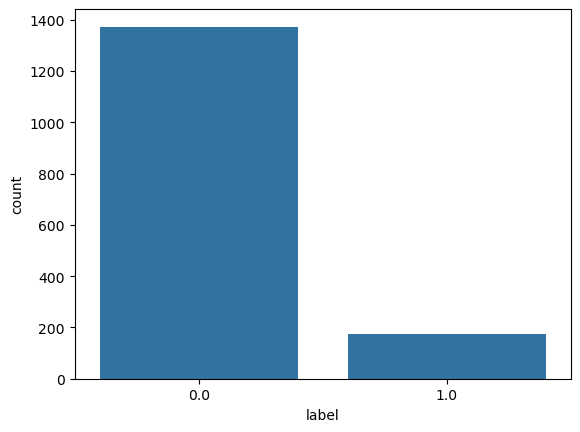

In [800]:
sns.barplot(df[target_col].value_counts())

Label target has a significant difference. There are a lot of 0 target values and low amount of 1 values. Use either using SMOTE or some other techniques that will help equal the number of data for the model to learn.

Check the violinplots for the numerical columns

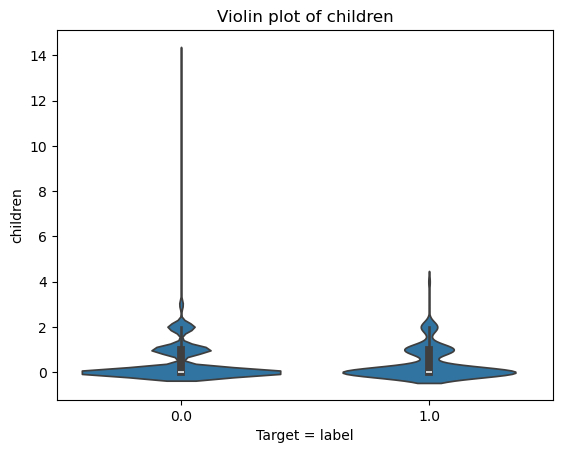

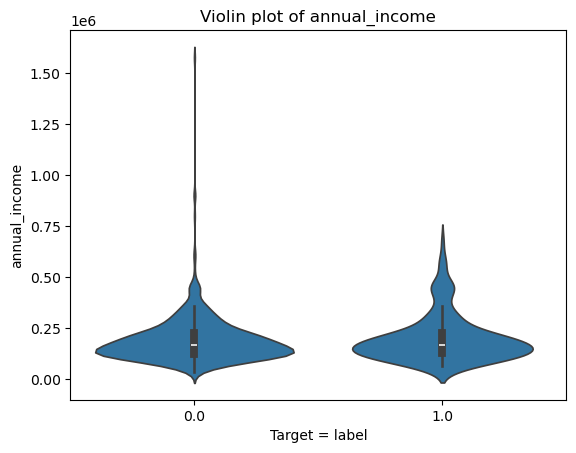

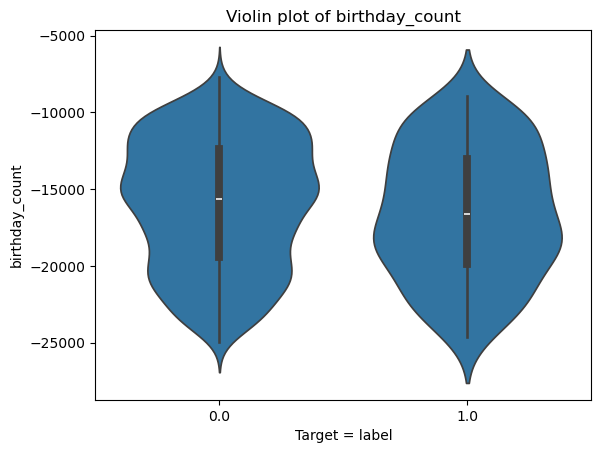

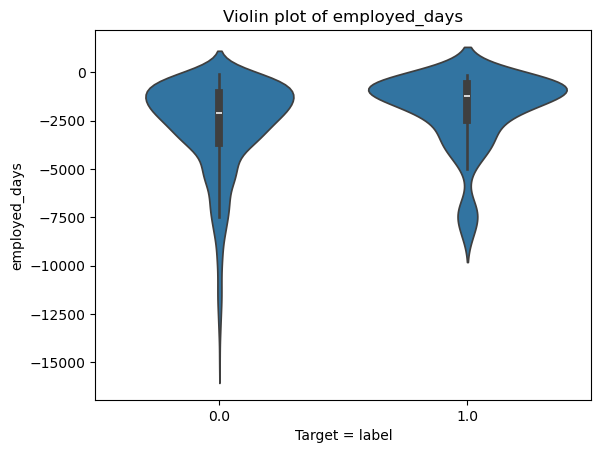

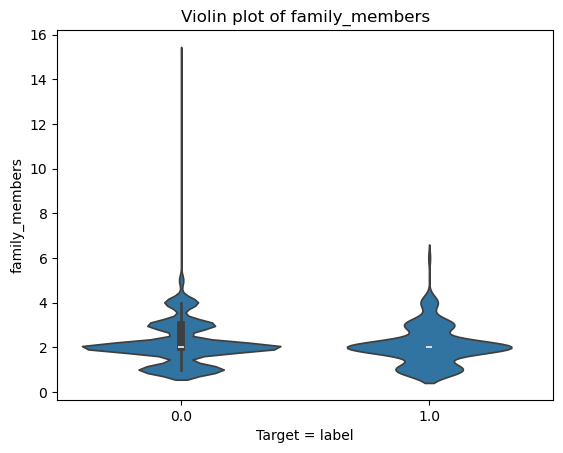

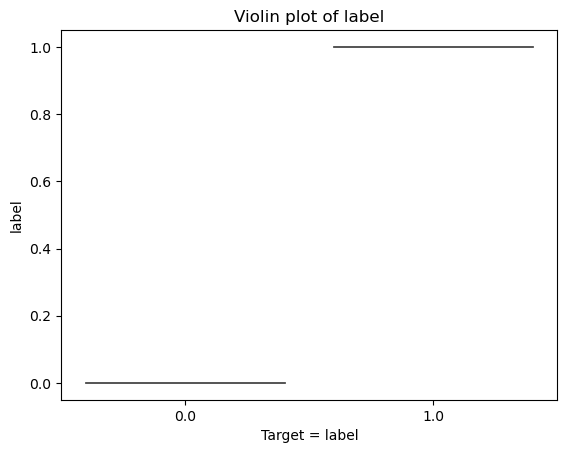

In [801]:
for col in eda_numerical_cols:
    sns.violinplot(y=col, data=eda_df, x=target_col)
    plt.title(f'Violin plot of {col}')
    plt.xlabel('Target = label')
    plt.ylabel(col)
    plt.show()


Most of the numerical features show strong overlap between the two classes, indicating that they may not be strong predictors on their own. However, there are some features that show some separation between the classes, which could be useful for modeling. It may be beneficial to explore feature engineering or interaction terms to improve the predictive power of the model.

In [802]:
# Log transform the annual_income column to reduce the skewness
df['annual_income_logged'] = np.log(df['annual_income'] + 1)
eda_df['annual_income_logged'] = np.log(eda_df['annual_income'] + 1)

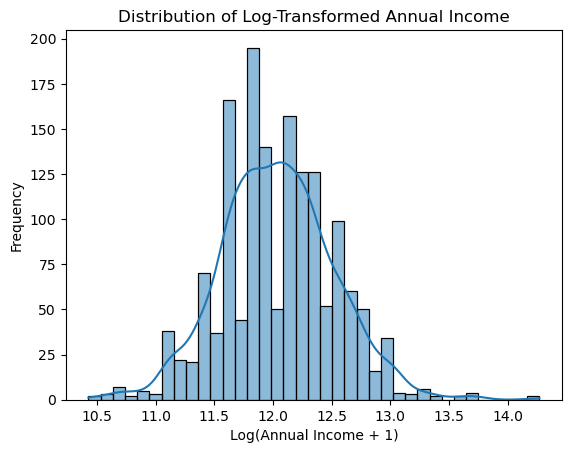

In [803]:
sns.histplot(eda_df['annual_income_logged'], kde=True)
plt.title('Distribution of Log-Transformed Annual Income')
plt.xlabel('Log(Annual Income + 1)')
plt.ylabel('Frequency')
plt.show()

Now let's look at the categorical features

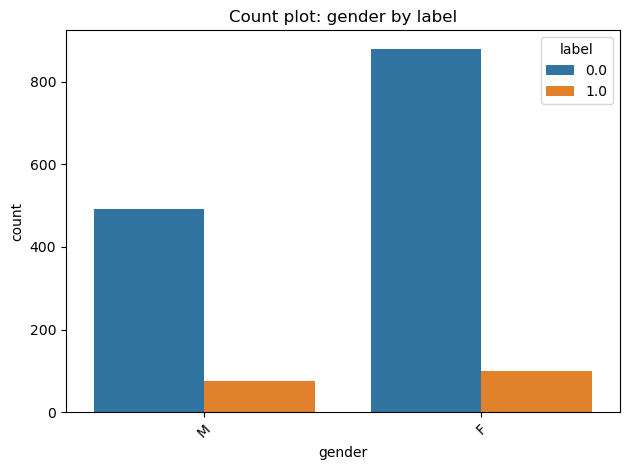

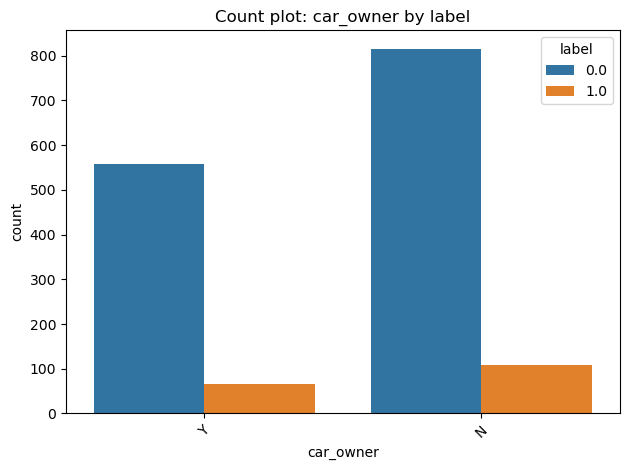

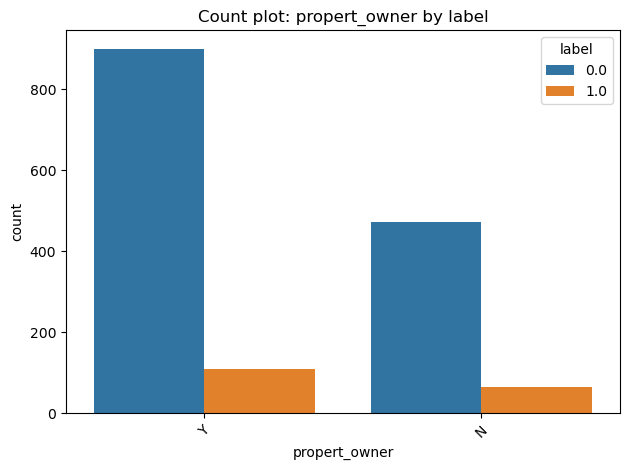

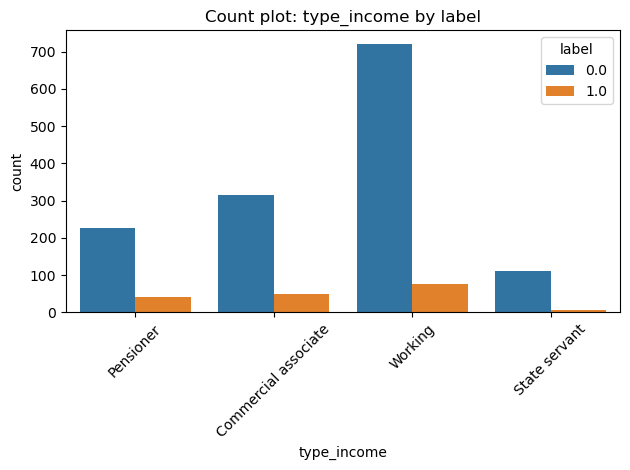

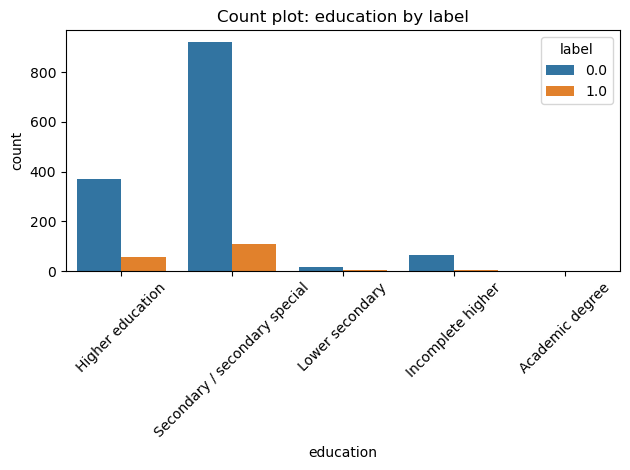

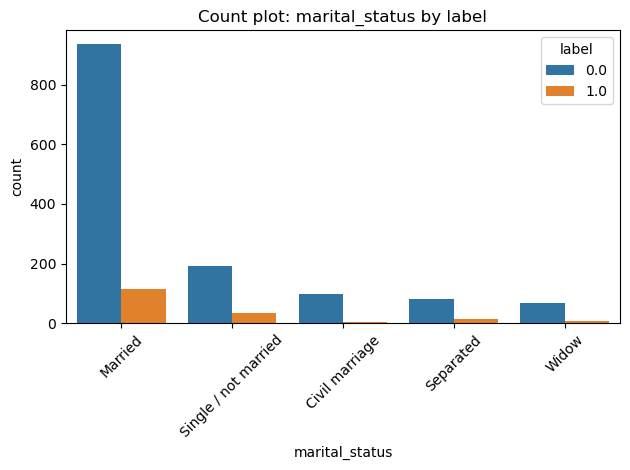

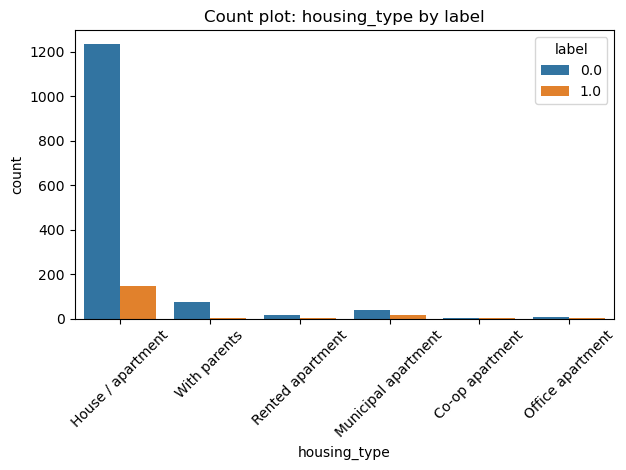

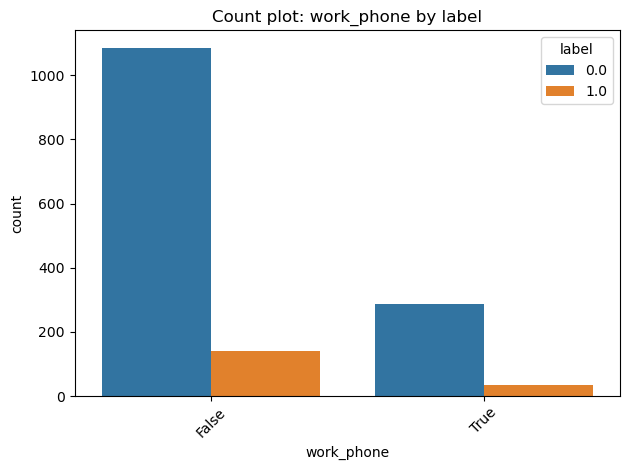

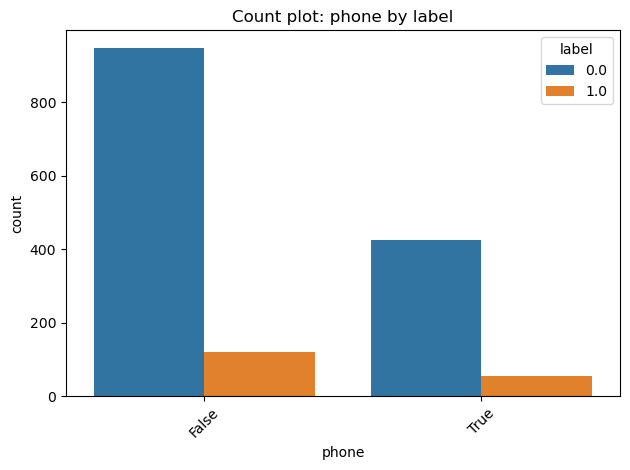

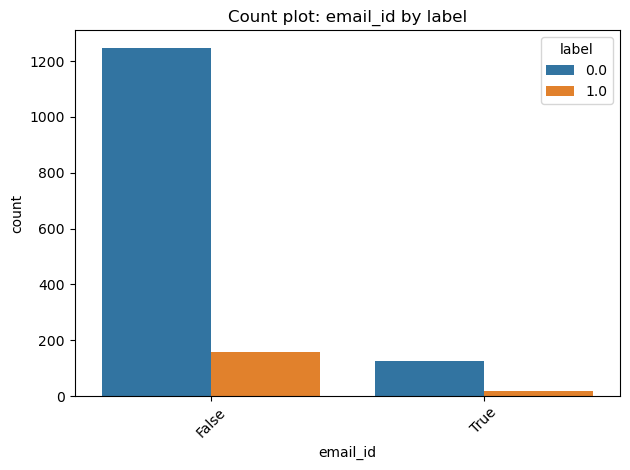

In [804]:
for col in eda_categorical_cols:

    # A) Count by category + class
    sns.countplot(data=eda_df, x=col, hue=target_col)
    plt.title(f"Count plot: {col} by label")
    plt.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

Some categorical columns such as `type_income`, `marital_status`, and `housing_type` shows visible variation. While other categorical columns shows no visible variation. This may indicate that the former categorical columns may be more useful for modeling than the latter categorical columns.

It is also important to note of the `employed_days` column as it has a lot of missing values and a lot of values that are 365243. In the setup, these values are changed to NaN but is not imputed. This may be a problem as the model will not be able to learn from these values. It may be beneficial to impute these values with the median or mean of the column to ensure that the model can learn from these values.

Strategy: Need to flag which rows has `employed_days` values that are 365243 to ensure that the model can learn from these values. Preferrably, change the value to a more meaningful value such as the median or mean of the column.

Additional Info: based on the data set, any employed_days value that is positive would be equivalent to the person not being employed. We can use this info to create an unemployed column that will flag the rows with employed_days values that are 365243 as 1 and the rest as 0. This way, the model can learn from the fact that these rows are unemployed without having to impute the values in the employed_days column.

# Feature Engineering

In [805]:
# create a new column for identifying whether the person is unemployed or not based on the employed_days column. If the value is NaN, then it is likely that the person is unemployed.
df["unemployed"] = df["employed_days"].isna().astype(int)

# Use the median to impute the missing values in the employed_days column as it is less affected by outliers than the mean.
df["employed_days"].fillna(df["employed_days"].median(), inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_14700\2765631416.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["employed_days"].fillna(df["employed_days"].median(), inplace=True)


In [806]:
df.columns

Index(['gender', 'car_owner', 'propert_owner', 'children', 'annual_income',
       'type_income', 'education', 'marital_status', 'housing_type',
       'birthday_count', 'employed_days', 'work_phone', 'phone', 'email_id',
       'family_members', 'label', 'annual_income_logged', 'unemployed'],
      dtype='object')

In [807]:
df

,gender,car_owner,propert_owner,children,annual_income,type_income,education,marital_status,housing_type,birthday_count,employed_days,work_phone,phone,email_id,family_members,label,annual_income_logged,unemployed
0,M,Y,Y,0.0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,-1953.0,0.0,0.0,0.0,2.0,1.0,12.100718,1
1,F,Y,N,0.0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586.0,1.0,1.0,0.0,2.0,1.0,12.660331,0
2,F,Y,N,0.0,315000.0,Commercial associate,Higher education,Married,House / apartment,-15661.5,-586.0,1.0,1.0,0.0,2.0,1.0,12.660331,0
3,F,Y,N,0.0,166500.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586.0,1.0,1.0,0.0,2.0,1.0,12.022757,0
4,F,Y,N,0.0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586.0,1.0,1.0,0.0,2.0,1.0,12.660331,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1543,F,N,Y,0.0,166500.0,Commercial associate,Higher education,Married,House / apartment,-11957.0,-2182.0,0.0,0.0,0.0,2.0,0.0,12.022757,0
1544,F,N,N,0.0,225000.0,Commercial associate,Incomplete higher,Single / not married,House / apartment,-10229.0,-1209.0,0.0,0.0,0.0,1.0,0.0,12.323860,0
1545,M,Y,Y,2.0,180000.0,Working,Higher education,Married,House / apartment,-13174.0,-2477.0,0.0,0.0,0.0,4.0,0.0,12.100718,0
1546,M,Y,N,0.0,270000.0,Working,Secondary / secondary special,Civil marriage,House / apartment,-15292.0,-645.0,1.0,1.0,0.0,2.0,0.0,12.506181,0


# Encoding

In [808]:
# Binary encoding
binary_cols = ['gender', 'car_owner', 'propert_owner', 'work_phone', 'phone', 'email_id', 'unemployed']
one_hot_cols = ['type_income', 'marital_status', 'housing_type']

In [809]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [810]:
df['education'].unique()

array(['Higher education', 'Secondary / secondary special',
       'Lower secondary', 'Incomplete higher', 'Academic degree'],
      dtype=object)

In [811]:
# use oridinal encoding for the education column as it has a natural order
education_order = ['Lower secondary', 'Secondary / secondary special', 'Incomplete higher', 'Higher education', 'Academic degree']
df['education'] = df['education'].map({level: idx for idx, level in enumerate(education_order)})

In [812]:
encoded_df = df.copy()

le = LabelEncoder()

# Gender
encoded_df["gender"] = encoded_df['gender'].map({'M': 1, 'F': 0})

for col in binary_cols:
    encoded_df[col] = le.fit_transform(encoded_df[col])

ohe = OneHotEncoder(sparse_output=False)
ohe_df = pd.DataFrame(ohe.fit_transform(df[[categorical_cols[2]]]), columns=ohe.get_feature_names_out([categorical_cols[2]]))

for col in one_hot_cols:
    transformed = ohe.fit_transform(encoded_df[[col]])
    ohe_df = pd.DataFrame(transformed, columns=ohe.get_feature_names_out([col]))
    encoded_df = pd.concat([encoded_df, ohe_df], axis=1)
    encoded_df.drop(columns=col, inplace=True)

encoded_df

,gender,car_owner,propert_owner,children,annual_income,education,birthday_count,employed_days,work_phone,phone,...,marital_status_Married,marital_status_Separated,marital_status_Single / not married,marital_status_Widow,housing_type_Co-op apartment,housing_type_House / apartment,housing_type_Municipal apartment,housing_type_Office apartment,housing_type_Rented apartment,housing_type_With parents
0,1,1,1,0.0,180000.0,3,-18772.0,-1953.0,0,0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0,1,0,0.0,315000.0,3,-13557.0,-586.0,1,1,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0,1,0,0.0,315000.0,3,-15661.5,-586.0,1,1,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0,1,0,0.0,166500.0,3,-13557.0,-586.0,1,1,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0,1,0,0.0,315000.0,3,-13557.0,-586.0,1,1,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1543,0,0,1,0.0,166500.0,3,-11957.0,-2182.0,0,0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1544,0,0,0,0.0,225000.0,2,-10229.0,-1209.0,0,0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1545,1,1,1,2.0,180000.0,3,-13174.0,-2477.0,0,0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1546,1,1,0,0.0,270000.0,1,-15292.0,-645.0,1,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


check that there are no null columns after encoding

In [813]:
encoded_df.isnull().sum()

gender                                 0
car_owner                              0
propert_owner                          0
children                               0
annual_income                          0
education                              0
birthday_count                         0
employed_days                          0
work_phone                             0
phone                                  0
email_id                               0
family_members                         0
label                                  0
annual_income_logged                   0
unemployed                             0
type_income_Commercial associate       0
type_income_Pensioner                  0
type_income_State servant              0
type_income_Working                    0
marital_status_Civil marriage          0
marital_status_Married                 0
marital_status_Separated               0
marital_status_Single / not married    0
marital_status_Widow                   0
housing_type_Co-

In [814]:
encoded_df

,gender,car_owner,propert_owner,children,annual_income,education,birthday_count,employed_days,work_phone,phone,...,marital_status_Married,marital_status_Separated,marital_status_Single / not married,marital_status_Widow,housing_type_Co-op apartment,housing_type_House / apartment,housing_type_Municipal apartment,housing_type_Office apartment,housing_type_Rented apartment,housing_type_With parents
0,1,1,1,0.0,180000.0,3,-18772.0,-1953.0,0,0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0,1,0,0.0,315000.0,3,-13557.0,-586.0,1,1,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0,1,0,0.0,315000.0,3,-15661.5,-586.0,1,1,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0,1,0,0.0,166500.0,3,-13557.0,-586.0,1,1,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0,1,0,0.0,315000.0,3,-13557.0,-586.0,1,1,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1543,0,0,1,0.0,166500.0,3,-11957.0,-2182.0,0,0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1544,0,0,0,0.0,225000.0,2,-10229.0,-1209.0,0,0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1545,1,1,1,2.0,180000.0,3,-13174.0,-2477.0,0,0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1546,1,1,0,0.0,270000.0,1,-15292.0,-645.0,1,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [815]:
encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 30 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   gender                               1548 non-null   int64  
 1   car_owner                            1548 non-null   int64  
 2   propert_owner                        1548 non-null   int64  
 3   children                             1548 non-null   float64
 4   annual_income                        1548 non-null   float64
 5   education                            1548 non-null   int64  
 6   birthday_count                       1548 non-null   float64
 7   employed_days                        1548 non-null   float64
 8   work_phone                           1548 non-null   int64  
 9   phone                                1548 non-null   int64  
 10  email_id                             1548 non-null   int64  
 11  family_members                

# Preprocessing

First since we're going to deal with our target variables, we need to basically split them into test and training data. Also know that there's a large disparity in our target variable as we recalled

<Axes: xlabel='label', ylabel='count'>

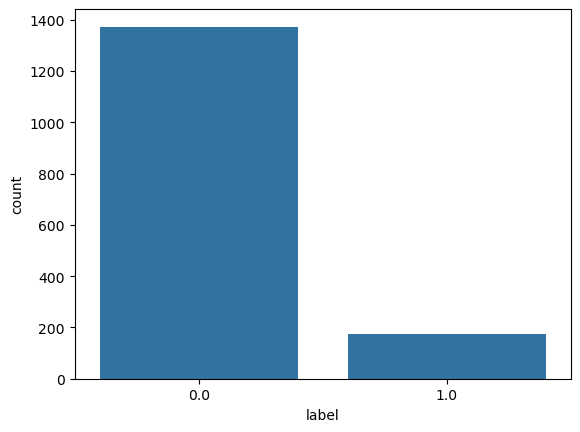

In [816]:
sns.barplot(df[target_col].value_counts())

Splitting comes first. We need to set out X(inputs) and our y(targets). We know that we're actually classifying based on the column 'label'

In [817]:
X = encoded_df.drop(columns=[target_col])
y = encoded_df[target_col]

In [818]:
from sklearn.model_selection import train_test_split

We want to ensure that we have 80 percent train data and only 20 percent for test data. If we weren't going to do hyperparameter tuning, then we could've further splitted our data into a validation set

In [819]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Knwoing that there's a high disparity and a clear majority and a minority between our labels. It seems that our samples actually get their credit approved (seeing as most rows or data) belong to '0' and only a few belong to '1' that are actually rejected

In [820]:
from imblearn.over_sampling import  SMOTE
smote = SMOTE(random_state=42)

In [821]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

As you can see the distribution of the target variable is now even. This is because what the SMOTE does duplicating the minority to even out the gap between the majority sample

Text(0.5, 1.0, 'Distribution of Loan Status')

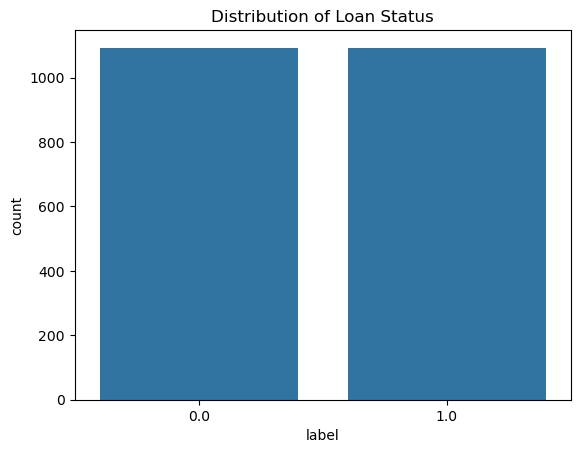

In [822]:
sns.countplot(x = y_train_smote)
plt.title('Distribution of Loan Status')    

Scaling- Next we actually have to scale our values. This is only really applicable for models that take into account distance. Modesl for example like KNN which calculates the distance for neighbors are sensitive to how far values are apart. In order to remdediate this we also scale our data. For models that based on tree like structures this isn't needed

In [823]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

This shows the scale or the distance between our values as off current

In [824]:
print("Old Scale: ")
print(np.min(X_train_smote)," <-> " ,np.max(X_train_smote))

Old Scale: 
-24946.0  <->  1575000.0


In [825]:
# only apply scaling to X values
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

The scaler evens out the scale so that higher numbers don't mean so much more than smaller numbers than they should be (normalizes it)

In [826]:
print("New Scale:")
print(np.min(X_train_scaled)," <-> " ,np.max(X_train_scaled))

New Scale:
-6.674144252412955  <->  19.46493396621666


### Classifiers and HyperParameter Tuning

For Hyperparameter tuning, let's bring out the GridSearchCV and RandomizedSearchCV from scikitlearn

In [827]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

Lets also bring out the evaluation metrics for classifiers

In [828]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

<small>A note about this is that: 

Precision: Correct positive predictions / total predicted positives.

Recall (Sensitivity): Correct positive predictions / total actual positives.

F1-Score: Harmonic mean of precision and recall.

Since we know that a good model must have a good recall and precision then a good model must have a good F1 score. The classification report summarizes these values

Confusion Matrix: Tabular summary of predictions vs. actuals. Shows True Positive, True Negatives, False Postive and False Negatives. The Foundation of Type I and Type II errors

Scaled classifiers are classifiers that actually care about the distance between data.


Logistic Regression

In [829]:
from sklearn.linear_model import LogisticRegression

Apply Hyperparameter Tuning

GridSearch

In [830]:
from sklearn.pipeline import Pipeline
# Create pipeline: scaling + logistic regression
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=500))
])

# Define parameter grid
param_grid = {
    'logreg__C': [0.01, 0.1, 1, 10, 100],   # Regularization strength
    'logreg__penalty': ['l1', 'l2'],        # Penalty type
    'logreg__solver': ['liblinear', 'saga'] # Solvers that support l1/l2
}

# Initialize GridSearchCV
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

# Fit model
grid.fit(X_train_scaled, y_train_smote)

# Best parameters and score
print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)
grid_search_pred = grid.predict(X_test_scaled)
print("Test Accuracy:", grid.score(X_test_scaled, y_test))


Best Parameters: {'logreg__C': 0.1, 'logreg__penalty': 'l1', 'logreg__solver': 'saga'}
Best CV Accuracy: 0.7187277305831584
Test Accuracy: 0.7387096774193549


RandomizedSearch

In [831]:


# Create pipeline: scaling + logistic regression
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=500))
])

# Define parameter distributions
param_distributions = {     # Sample C from a log-uniform distribution
    'logreg__penalty': ['l1', 'l2'],         # Penalty type
    'logreg__solver': ['liblinear', 'saga']  # Solvers that support l1/l2
}

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=20,              # Number of parameter settings sampled
    scoring='accuracy',
    cv=5,
    random_state=42,
    n_jobs=-1
)

# Fit model
random_search.fit(X_train_scaled, y_train_smote)

# Best parameters and score
print("Best Parameters:", random_search.best_params_)
print("Best CV Accuracy:", random_search.best_score_)
random_search_pred = random_search.predict(X_test_scaled)
print("Test Accuracy:", random_search.score(X_test_scaled, y_test))



c:\Users\User\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=20. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Parameters: {'logreg__solver': 'liblinear', 'logreg__penalty': 'l1'}
Best CV Accuracy: 0.7072892176838762
Test Accuracy: 0.7516129032258064


Based on the testing above, then we can kind of see from the test accuracy that the parameters in the Randomized search did better than the one in the GridSearch. Nevertheless, let's run metrics on both so that we can actually see it and analyze

Let's try the GridSearch Pipeline first

In [832]:
log_reg_grid_accuracy = accuracy_score(y_test, grid_search_pred)
print("Grid Search Test Accuracy:", log_reg_grid_accuracy)

Grid Search Test Accuracy: 0.7387096774193549


It's not a remarkable accuracy. It's there on the upper portion but it's not that high. There may be multiple reasons behind this even when it's fitted to the grid search tuning pipeline. Note that accuracy is just defined below. It may be clearer when we try to analyze the confusion matrix

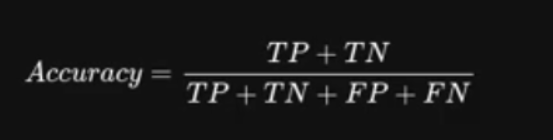

In [833]:
log_reg_grid_classification_report = classification_report(y_test, grid_search_pred)
print(" Logistic Regrssion Grid Search Classification Report:")
print(log_reg_grid_classification_report)

 Logistic Regrssion Grid Search Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.77      0.84       280
         1.0       0.17      0.43      0.24        30

    accuracy                           0.74       310
   macro avg       0.55      0.60      0.54       310
weighted avg       0.85      0.74      0.78       310



The model seem to have a really high precision for the 0 vaues and also a an accetable recall which is why the f1 score for the 0 labeled values are high. The main reason (assuming) is probably because in the first place the samples were biased towards labels of 0. Considering the labels of 1 being a minorit, we can actually see it because although the recall was large (recall is the amount of samples being considered) the precision was low. That means that in a clusp of '1.0' samples, it only managed to predict the correct label rarely, resulting in a 0.17 precision score. 

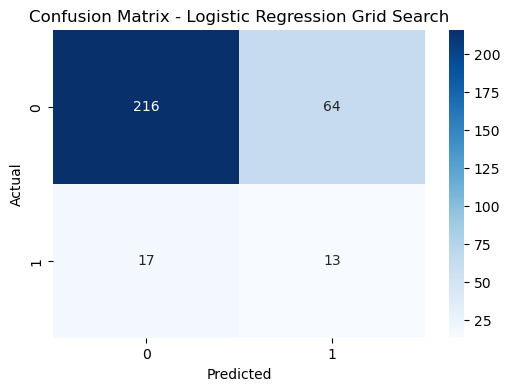

In [834]:
log_reg_grid_confusion_matrix = confusion_matrix(y_test, grid_search_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(log_reg_grid_confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression Grid Search')
plt.show()

<small>Now we can actually see the TP, TN, FP, FN. Note the definition: A Type I error is a false positive (rejecting a true null hypothesis), while a Type II error is a false negative (failing to reject a false null hypothesis). 

Here based on the classification report it actually makes sense. For the 0 labels the model has classified 216 of them as 0 (predicted) and also the answer being (0) at the same time. The is is a TRUE positive, that is the model has predicted labels of of 'yes' to be 'yes' considering the 0 means approved. It also seems that there are few type I errors in which the model classifies 0 as a 1. (specifically 64)

On the other hand we move on the 1. We can actually seethe model performing really poorly on the 1 making a bunch of type II errors, more than actually getting it correct. It seems to classify the 1 values as 0 more than it actually classifies it as one. The reasoning behind this is strongly related to the bias in the target variables that we've seen before

Let's Try the RandommizedSearch Pipeline Next. What did it do to improve accuracy exactly when compared to the GridSerach Pipeline

In [835]:
log_reg_randomized_accuracy = accuracy_score(y_test, random_search_pred)
print("Randomized Search Test Accuracy:", log_reg_randomized_accuracy)

Randomized Search Test Accuracy: 0.7516129032258064


It seems the that accuracy of the randomized pipeline is actually just a teeny bit better than the grid pipelline. We can probably see why when we look at the classification report and confusion matrix

In [836]:
log_reg_randomized_report = classification_report(y_test, random_search_pred)
print(" Logistic Regression Randomized Search Classification Report:")
print(log_reg_randomized_report)

 Logistic Regression Randomized Search Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.78      0.85       280
         1.0       0.19      0.47      0.27        30

    accuracy                           0.75       310
   macro avg       0.56      0.62      0.56       310
weighted avg       0.86      0.75      0.79       310



Here we can actually see an improvement in the precision for predicting '1' labels compared to before in the grid. There's alo better recall, which is probably why the f1 score for it is better and so contributes to the overall accuracy of the model.

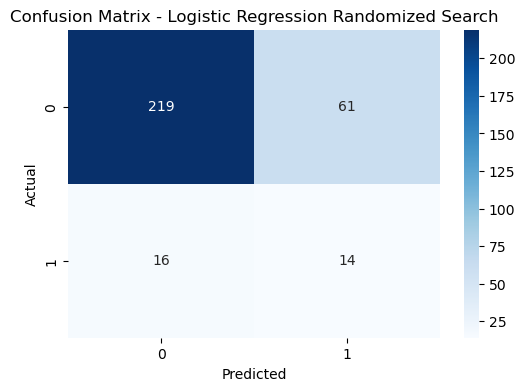

In [837]:
log_reg_randomized_confusion_matrix = confusion_matrix(y_test, random_search_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(log_reg_randomized_confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression Randomized Search')
plt.show()

The results here are kind of funny almost. It seems to have gotten 0 accurate just a tad bit more compared to the first pipeline. In the 1's label it got it correct just '1 value' compared to the Gridserach pipeline, that it classified an actual 1, 1 times more than the Gridserach did. The better precision probably contributed to the overall accuracy of the Randomized compared to the GridSearch, though it still has a LOT Of TROUBLE trying to predict a 1 which is assumed to stem from the 'biasing' problem in the samples

Non Scaled classifiers are classifiers that don't really care about the distance between data. They're thought more 'decisions'. 

In [838]:
from sklearn.ensemble import RandomForestClassifier


Apply Hyperparameter Tuning

GridSearch

In [839]:

# Define RandomForest model
rf = RandomForestClassifier(random_state=42)

# Define parameter grid
param_grid = {
    'n_estimators': [5, 10, 15],        # Number of trees
    'max_depth': [None, 5, 10, 15],        # Depth of trees
    'min_samples_split': [1, 2, 5],        # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 4],          # Minimum samples per leaf
    'max_features': ['sqrt', 'log2', None]  # Features considered at each split
}

# Initialize GridSearchCV
rf_grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit model - no need for scaling
rf_grid_search.fit(X_train_smote, y_train_smote)

# Best parameters and score
print("Best Parameters:", rf_grid_search.best_params_)
print("Best CV Accuracy:", rf_grid_search.best_score_)
rf_grid_search_pred = rf_grid_search.predict(X_test)
print("Test Accuracy:", rf_grid_search.score(X_test, y_test))


c:\Users\User\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
540 fits failed out of a total of 1620.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
540 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\User\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
    

Best Parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 15}
Best CV Accuracy: 0.9451626385797727
Test Accuracy: 0.9225806451612903


RandomizedSearch

In [840]:

from scipy.stats import randint


# Define RandomForest model
rf2 = RandomForestClassifier(random_state=42)

# Define parameter distributions
param_distributions = {
    'n_estimators': randint(5,20),       # Number of trees
    'max_depth': randint(5, 15),             # Depth of trees
    'min_samples_split': randint(1, 5),     # Minimum samples to split a node
    'min_samples_leaf': randint(1, 4),      # Minimum samples per leaf
    'max_features': ['sqrt', 'log2', None]   # Features considered at each split
}

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=30,              # Number of parameter settings sampled
    scoring='accuracy',
    cv=5,
    random_state=42,
    n_jobs=-1
)

# Fit model - no need for scaling 
random_search.fit(X_train_smote, y_train_smote)

# Best parameters and score
print("Best Parameters:", random_search.best_params_)
print("Best CV Accuracy:", random_search.best_score_)
rf_random_search_pred = random_search.predict(X_test)
print("Test Accuracy:", random_search.score(X_test, y_test))


Best Parameters: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 19}
Best CV Accuracy: 0.9401387626302204
Test Accuracy: 0.9225806451612903


c:\Users\User\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
25 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\User\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
    val

It seemed that the best accuracy goes for gridsearch. We could've probably tested a larger range but knowing how trees have the tendency to iterate we should keep it to a minimum. With that let's analyze GridSearch Pipeline first and see why it has a better accuracy than the randomsearch

In [841]:
random_forest_grid_accuracy = accuracy_score(y_test, rf_grid_search_pred)
print("Grid Search Test Accuracy:", random_forest_grid_accuracy)

Grid Search Test Accuracy: 0.9225806451612903


Accuracy here comes out to 0.92, which looks solid at first glance, but it’s really being carried by the model’s near‑perfect handling of class 0. Because class 0 dominates the dataset and the model predicts it almost flawlessly, the overall accuracy shoots up, even though recall for class 1 is stuck down at 0.27

In [842]:
random_forest_grid_report = classification_report(y_test, rf_grid_search_pred)
print("Random Forest Grid Search Classification Report:")
print(random_forest_grid_report)

Random Forest Grid Search Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.99      0.96       280
         1.0       0.80      0.27      0.40        30

    accuracy                           0.92       310
   macro avg       0.86      0.63      0.68       310
weighted avg       0.91      0.92      0.90       310



The results here are a bit telling in their imbalance. The GridSearch run nailed class 0 almost perfectly again, with precision at 0.93 and recall at 0.99, which pushed its F1 up to 0.96. But when it came to class 1, the story is different precision is decent at 0.80, yet recall drops way down to 0.27, leaving the F1 at just 0.40. That means the model is still very hesitant to call something a “1,” missing most of the actual positives. Overall accuracy looks strong at 0.92, but that’s mostly riding on the majority class. The macro averages (precision 0.86, recall 0.63, F1 0.68) expose the imbalance more clearly, while the weighted averages smooth it out thanks to the heavy skew toward class 0.

So, just like with the randomized search, the GridSearch pipeline shows solid precision but continues to struggle with recall on the minority class — a sign that the bias in the samples is still steering the model toward predicting “0” far more confidently than “1.” And at this point just kinda confirms it's because of the sampling technique

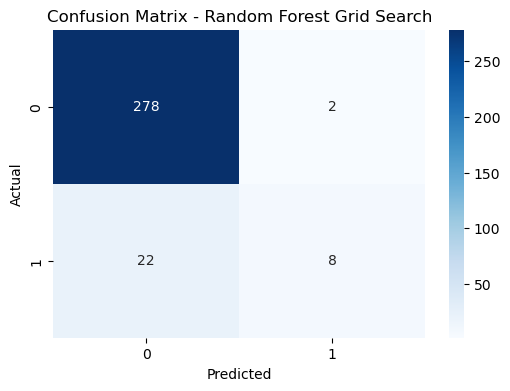

In [843]:
random_forest_grid_confusion_matrix = confusion_matrix(y_test, rf_grid_search_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(random_forest_grid_confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest Grid Search')
plt.show()

confusion matrix is basically showing the model’s personality loud and clear. It’s a total overachiever when it comes to approvals ,278 true negatives with only 2 false positives means it almost never wrongly denies someone who should be approved. But flip to the “not approved” side and the confidence crumbles: only 8 true positives against 22 false negatives. That’s the model waving through a bunch of cases that should have been rejected, rubber‑stamping them as approved instead.

Next Lets test the RandomizedSearch Pipeline

In [844]:
random_forest_randomized_accuracy = accuracy_score(y_test, rf_random_search_pred)
print("Randomized Search Test Accuracy:", random_forest_randomized_accuracy)

Randomized Search Test Accuracy: 0.9225806451612903


The accuracy here clocks in at 0.92, which on the surface looks polished and impressive, but it’s really being propped up by the model’s near‑perfect performance on class 0. Honestly, again because HIGHLY PROBABLY because of the sampling problem

In [845]:
random_forest_randomized_report = classification_report(y_test, rf_random_search_pred)
print("Random Forest Randomized Search Classification Report:")
print(random_forest_randomized_report)

Random Forest Randomized Search Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.99      0.96       280
         1.0       0.75      0.30      0.43        30

    accuracy                           0.92       310
   macro avg       0.84      0.64      0.69       310
weighted avg       0.91      0.92      0.91       310



same vibe as before, the model is really biased on class 0, with precision at 0.93 and recall at 0.99, which makes the F1 a slick 0.96. But then you look at class 1 and it’s like the model just shrugs: precision at 0.75 is decent, but recall is stuck at 0.30, dragging the F1 down to 0.43. The macro averages (precision 0.84, recall 0.64, F1 0.69) spill the tea on the imbalance, while the weighted averages smooth things over because class 0 dominates the support. In short, the Random Forest with randomized search is still playing favorites. it’s sharp and polished when predicting 0, but it keeps ghosting class 1, leaving recall in the dust.

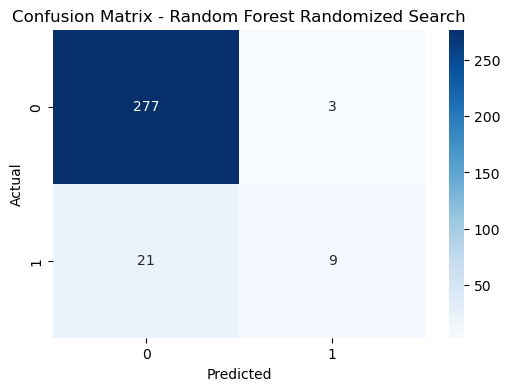

In [846]:
random_forest_randomized_confusion_matrix = confusion_matrix(y_test, rf_random_search_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(random_forest_randomized_confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest Randomized Search')
plt.show()

the model is fantastic at spotting approvals,277 true negatives with only 3 false alarms means it almost never wrongly flags an approved case as “not approved.” But when it comes to the “not approved” side, the model is dropping the ball: only 9 true positives against 21 misses. In other words, it’s catching some of the rejections, but most of them slip through as if they were approved. 